# Neural Network Using All Available Data

## Imports

In [57]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings

# toruchsurv for survival problems
from torchsurv.loss.cox import neg_partial_log_likelihood
from torchsurv.loss.weibull import neg_log_likelihood, log_hazard, survival_function
from torchsurv.metrics.brier_score import BrierScore
from torchsurv.metrics.auc import Auc
from torchsurv.stats.kaplan_meier import KaplanMeierEstimator

from lifelines.utils import concordance_index

In [58]:
# Custom dataset
class CustomDataset(Dataset):
    """ "Custome dataset for returning values we want"""

    # defining values in the constructor
    def __init__(self, df: pd.DataFrame):
        self.df = df

    # Getting data size/length
    def __len__(self):
        return len(self.df)

    # Getting the data samples
    def __getitem__(self, idx):
        sample = self.df.iloc[idx]
        # Targets
        event = torch.tensor(sample["efs"]).bool()
        time = torch.tensor(sample["efs_time"]).float()
        # Predictors
        x = torch.tensor(sample.drop(["efs", "efs_time","race_group"]).values).float()
        race = sample["race_group"]
        return x, (event, time), race

## Preprocess

In [59]:
data = pd.read_csv('data/clean_data.csv')

In [60]:
# Store IDs separately
ids = data['ID'].values

# Remove ID and experiment features
df = data.drop(['ID'],axis=1)
df = data.drop(['ethnicity'],axis=1)
df = data.drop(['psych_disturb'],axis=1)



# Split data into train, validation, and test sets
# First split: separate test set (10%)
df_temp, df_test, ids_temp, ids_test = train_test_split(
    df, ids, test_size=0.1, random_state=42
)

# Second split: get validation set from remaining data (20%)
val_size_adjusted = 0.2 / (1 - 0.1)
df_train, df_val, ids_train, ids_val = train_test_split(
    df_temp, ids_temp, test_size=val_size_adjusted, random_state=42
)

print(f"Original: {data.shape[0]}")
print(f"Training: {df_train.shape[0]} ({len(df_train)/len(data):.1%})")
print(f"Validation: {df_val.shape[0]} ({len(df_val)/len(data):.1%})")
print(f"Testing: {df_test.shape[0]} ({len(df_test)/len(data):.1%})")

Original: 28800
Training: 20160 (70.0%)
Validation: 5760 (20.0%)
Testing: 2880 (10.0%)


In [61]:
# Standardize features (For fitting into tensor)
#scaler = StandardScaler()
#X_train = scaler.fit_transform(X_train)
#X_val = scaler.transform(X_val)
#X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
#X_train_tensor = torch.FloatTensor(X_train)
#y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)
#X_val_tensor = torch.FloatTensor(X_val)
#y_val_tensor = torch.FloatTensor(y_val).unsqueeze(1)
#X_test_tensor = torch.FloatTensor(X_test)

#X_train_tensor.shape

## Simple Model

In [62]:
# Define a simple neural network with fully connected layers
class SimpleEFSModel(nn.Module):
    def __init__(self, input_size):
        super(SimpleEFSModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 1)
        self.bn1 = nn.BatchNorm1d(128)
        self.bn2 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn1(self.fc2(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.fc3(x)))
        x = self.dropout(x)
        x = self.fc4(x)
        return x

## Train Model

In [63]:
# Create data loaders
train_dataset = CustomDataset(df_train)
val_dataset = CustomDataset(df_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

The training and validation done below are a proof-of-concept for a simple binary classification model predicting EFS

In [66]:
# Initialize model
# Also, quick sanity check on dimensions
x, (event,time), race = next(iter(train_loader))
print(f"x dim:{x.shape[1]}\ndf dim:{df_train.shape[1]}")
input_size = x.shape[1]
model = SimpleEFSModel(input_size)

# Define hyper-parameters
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
epochs = 50

x dim:56
df dim:59


Epoch 1/50 — train loss: 3.8460 — val loss: 3.8237 — stratified C-index: 0.5179
Epoch 2/50 — train loss: 3.8084 — val loss: 3.8233 — stratified C-index: 0.5377
Epoch 3/50 — train loss: 3.7947 — val loss: 3.8236 — stratified C-index: 0.5099
Epoch 4/50 — train loss: 3.7853 — val loss: 3.8239 — stratified C-index: 0.5372
Epoch 5/50 — train loss: 3.7840 — val loss: 3.8234 — stratified C-index: 0.5680
Epoch 6/50 — train loss: 3.7782 — val loss: 3.8231 — stratified C-index: 0.5875
Epoch 7/50 — train loss: 3.7749 — val loss: 3.8232 — stratified C-index: 0.5855
Epoch 8/50 — train loss: 3.7764 — val loss: 3.8229 — stratified C-index: 0.5621
Epoch 9/50 — train loss: 3.7774 — val loss: 3.8233 — stratified C-index: 0.5660
Epoch 10/50 — train loss: 3.7702 — val loss: 3.8234 — stratified C-index: 0.5537
Epoch 11/50 — train loss: 3.7648 — val loss: 3.8231 — stratified C-index: 0.5817
Epoch 12/50 — train loss: 3.7647 — val loss: 3.8224 — stratified C-index: 0.5731
Epoch 13/50 — train loss: 3.7678 — va

TypeError: 'Text' object is not callable

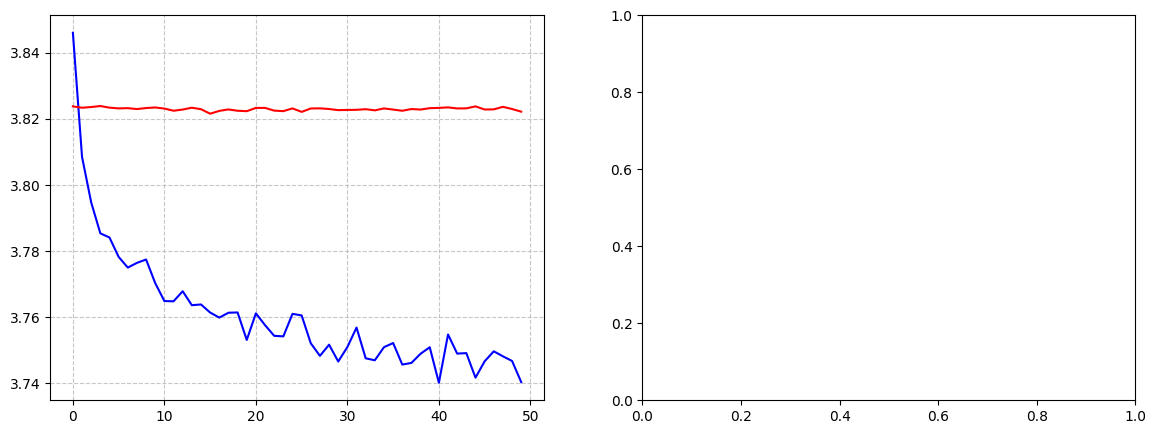

In [67]:
train_losses = []
val_losses   = []
strat_cs     = []

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Ignore warnings related to ties but keep the other ones
warnings.filterwarnings("ignore",message=".*Ties in event*", category=UserWarning)

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for batch in train_loader:
        x, (event,time), race = batch
        optimizer.zero_grad()
        outputs = model(x)
        loss = neg_partial_log_likelihood(outputs, event, time, ties_method="efron", reduction="mean")
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0

    # containers for stratified‐C computation
    all_outputs = []
    all_events  = []
    all_times   = []
    all_races   = []

    with torch.no_grad():
        for x, (event, time), race in val_loader:
            preds = model(x)    # risk scores
            all_outputs.extend(preds)
            all_events .extend(event.int().cpu().numpy())
            all_times  .extend(time.cpu().numpy())
            all_races  .extend(race)            # str or int labels

            # still compute loss
            loss = neg_partial_log_likelihood(preds, event, time,
                                              ties_method="efron",
                                              reduction="mean")
            val_loss += loss.item()

    # compute per‐group C‐indices
    all_outputs = np.array(all_outputs)
    all_events  = np.array(all_events)
    all_times   = np.array(all_times)
    all_races   = np.array(all_races)

    c_idxs = []
    for grp in np.unique(all_races):
        mask = (all_races == grp)
        ci = concordance_index(
            all_times[mask],      # event/censoring times
            -all_outputs[mask],   # negative if higher score → shorter survival
            all_events[mask]
        )
        c_idxs.append(ci)

    stratified_c = np.mean(c_idxs) - np.std(c_idxs)
    val_losses.append(val_loss)
    strat_cs.append(stratified_c)
    print(f"Epoch {epoch+1}/{epochs} "
          f"— train loss: {train_loss/len(train_loader):.4f} "
          f"— val loss: {val_loss/len(val_loader):.4f} "
          f"— stratified C-index: {stratified_c:.4f}")
    
# Plot training loop results
fig, axs = plt.subplots(1, 2, figsize=(14, 5))  # 1 row, 2 columns

axs[0].plot(range(epochs), [tl / len(train_loader) for tl in train_losses], 'b-', label='Training Loss')
axs[0].plot(range(epochs), [vl / len(val_loader) for vl in val_losses], 'r-', label='Validation Loss')
axs[0].grid(True, linestyle='--', alpha=0.7)
axs[0].title('Training and Validation Loss')
axs[0].xlabel('Epochs')
axs[0].ylabel('Loss')
axs[0].legend()

axs[1].plot(range(epochs), strat_cs)
axs[1].title('Stratified C Index Over Time')
axs[1].xlabel('Epoch')
axs[1].ylabel('Stratified C Index')

plt.show()


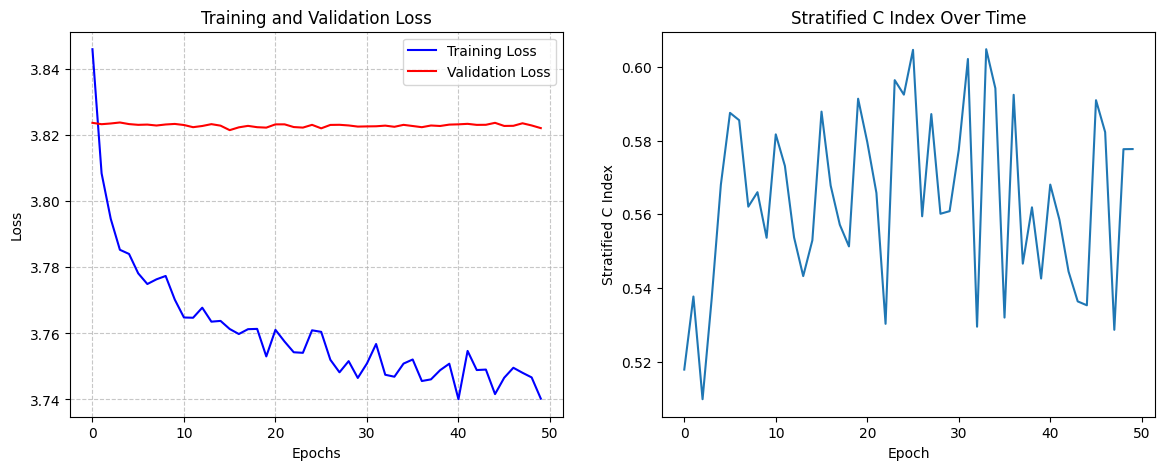

In [69]:
# Plot training loop results
fig, axs = plt.subplots(1, 2, figsize=(14, 5))  # 1 row, 2 columns

axs[0].plot(range(epochs), [tl / len(train_loader) for tl in train_losses], 'b-', label='Training Loss')
axs[0].plot(range(epochs), [vl / len(val_loader) for vl in val_losses], 'r-', label='Validation Loss')
axs[0].grid(True, linestyle='--', alpha=0.7)
axs[0].set_title('Training and Validation Loss')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(range(epochs), strat_cs)
axs[1].set_title('Stratified C Index Over Time')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Stratified C Index')

plt.show()
